<a href="https://colab.research.google.com/github/OJB-Quantum/Spintronics-Generative-Layouts/blob/main/Nano_MTJ_Test_Array_with_Labels_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [ ]:
# This code cell installs the required packages needed for the layout generation.

!python -m pip install -q uv
!uv pip install --system -q phidl gdstk ezdxf gdspy || python -m pip install -q phidl gdstk ezdxf gdspy

Generated layout: /content/MTJ_array.gds
Spacing mode: electrode_edge_gap
Electrode bounding box: 360.000 µm wide × 110.000 µm tall
Actual electrode edge gaps: X = 40.000 µm, Y = 290.000 µm
Derived center-to-center pitch: X = 400.000 µm, Y = 400.000 µm
Cell label settings: height = 60.000 µm, top clearance below electrode = 100.000 µm, left offset = 5.000 µm
Example labels:
  bottom-left cell: ^0   >0
  next column:      ^0   >1
  next row:         ^1   >0
Layer map:
  FINS: GDS layer 4, datatype 0
  PADS: GDS layer 5, datatype 0
  PILLARS: GDS layer 30, datatype 0
  ELECTRODE: GDS layer 52, datatype 0
  LABELS: GDS layer 70, datatype 0


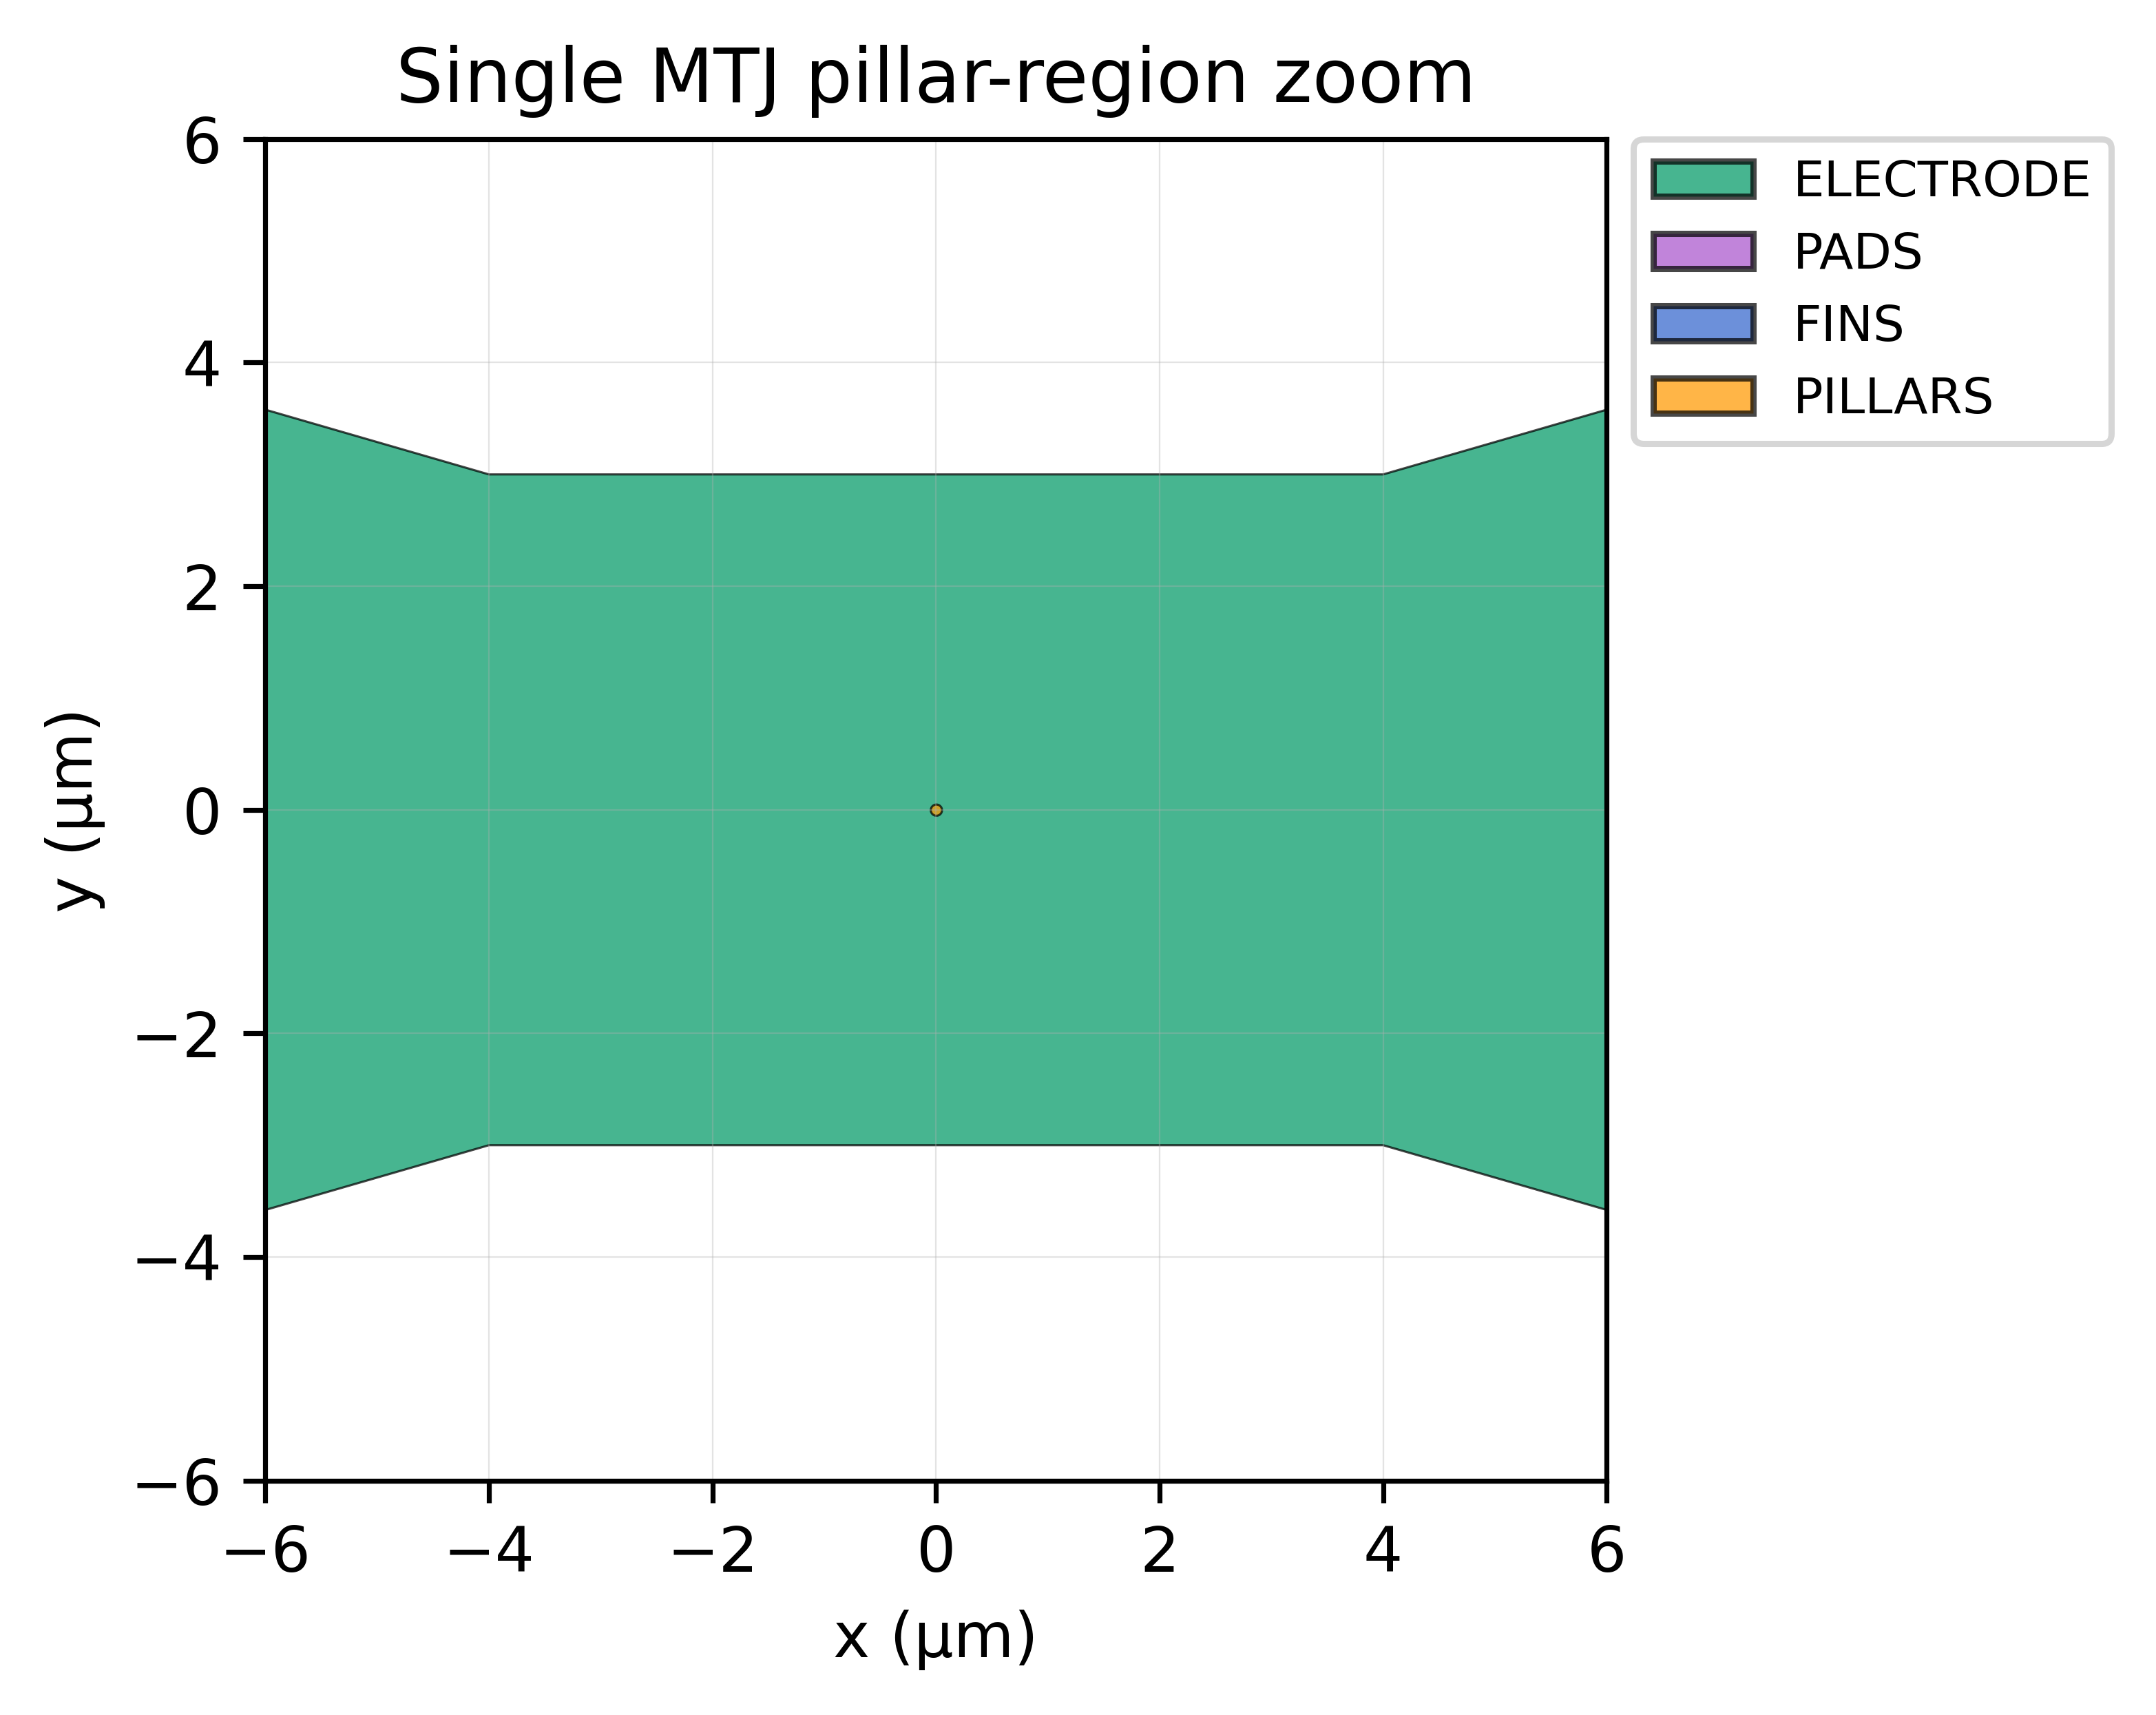

In [ ]:
"""
Parameterized magnetic tunnel junction array.

The unit cell contains the fixed electrode, pad, and fin geometries. The pillar
diameter, XY array dimensions, electrode edge-to-edge spacing, and automatic
alphanumeric cell labels are adjustable. PHIDL is used for layout geometry, and
GDSTK is used for exporting the layout as GDSII or OASIS.
"""

import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Final, Literal

import gdstk
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import PolyCollection
from matplotlib.patches import Patch
from phidl import Device

# ---------------------------------------------------------------------------
# Control knobs.
# ---------------------------------------------------------------------------
OUTPUT_BASENAME: Final[str] = "MTJ_array"
OUTPUT_FORMAT: Final[Literal["gds", "oas"]] = "gds"
OUTPUT_DIRECTORY: Final[Path] = Path.cwd()

# Set the desired MTJ pillar diameter and array size here.
PILLAR_DIAMETER_NM: Final[float] = 100.0
ARRAY_SIZE_X: Final[int] = 16
ARRAY_SIZE_Y: Final[int] = 16
CENTER_ARRAY_AT_ORIGIN: Final[bool] = True

ARRAY_SPACING_MODE: Final[Literal["electrode_edge_gap", "center_pitch"]] = (
    "electrode_edge_gap"
)

# Used when ARRAY_SPACING_MODE = "electrode_edge_gap".
ELECTRODE_EDGE_GAP_X_UM: Final[float] = 40.0
ELECTRODE_EDGE_GAP_Y_UM: Final[float] = 290.0

# Used when ARRAY_SPACING_MODE = "center_pitch".
ARRAY_CENTER_PITCH_X_UM: Final[float] = 430.0
ARRAY_CENTER_PITCH_Y_UM: Final[float] = 180.0

CIRCLE_POINTS: Final[int] = 160

GDS_UNIT_M: Final[float] = 1e-6
GDS_PRECISION_M: Final[float] = 1e-9

DISPLAY_AFTER_BUILD: Final[bool] = True
DISPLAY_SINGLE_UNIT_ZOOM: Final[bool] = True
WRITE_KLAYOUT_LAYER_PROPERTIES: Final[bool] = True
DOWNLOAD_AFTER_EXPORT_IN_COLAB: Final[bool] = False

# Automatic label controls.
ADD_CELL_LABELS: Final[bool] = True
LABEL_TEXT_HEIGHT_UM: Final[float] = 60.0
LABEL_VERTICAL_CLEARANCE_BELOW_ELECTRODE_UM: Final[float] = 100.0
LABEL_LEFT_OFFSET_FROM_ELECTRODE_UM: Final[float] = 5.0
LABEL_SEPARATOR: Final[str] = "   "

# High-resolution preview controls.
PREVIEW_DPI: Final[int] = 800
PREVIEW_FIGSIZE_IN: Final[tuple[float, float]] = (12.0, 9.0)
PREVIEW_PADDING_UM: Final[float] = 100.0
PREVIEW_EDGE_LINEWIDTH: Final[float] = 0.18
PREVIEW_ALPHA: Final[float] = 0.72
PREVIEW_LABEL_ALPHA: Final[float] = 0.95
PREVIEW_SHOW_LEGEND: Final[bool] = True
PREVIEW_LEGEND_OUTSIDE: Final[bool] = True

UNIT_ZOOM_WINDOW_UM: Final[float] = 12.0
UNIT_ZOOM_FIGSIZE_IN: Final[tuple[float, float]] = (6.0, 6.0)
UNIT_ZOOM_DPI: Final[int] = 650

# Fixed DXF-derived geometry controls.
FIN_WIDTH_UM: Final[float] = 1.0
FIN_LENGTH_UM: Final[float] = 15.0
FIN_PITCH_UM: Final[float] = 2.5
FINS_PER_GROUP: Final[int] = 5

mpl.rcParams["figure.dpi"] = PREVIEW_DPI
mpl.rcParams["savefig.dpi"] = PREVIEW_DPI


@dataclass(frozen=True)
class LayerSpec:
    """Container for a named GDS layer/datatype pair."""

    name: str
    layer: int
    datatype: int
    color: str


@dataclass(frozen=True)
class BoundingBox:
    """Axis-aligned bounding box in micrometers."""

    xmin: float
    ymin: float
    xmax: float
    ymax: float

    @property
    def width(self) -> float:
        """Return bounding-box width."""
        return self.xmax - self.xmin

    @property
    def height(self) -> float:
        """Return bounding-box height."""
        return self.ymax - self.ymin


LAYERS: Final[dict[str, LayerSpec]] = {
    "FINS": LayerSpec("FINS", 4, 0, "#3366cc"),
    "PADS": LayerSpec("PADS", 5, 0, "#aa55cc"),
    "PILLARS": LayerSpec("PILLARS", 30, 0, "#ff9900"),
    "ELECTRODE": LayerSpec("ELECTRODE", 52, 0, "#009966"),
    "LABELS": LayerSpec("LABELS", 70, 0, "#111111"),
}

ELECTRODE_POLYGON_UM: Final[list[tuple[float, float]]] = [
    (-180.0, 55.0),
    (-180.0, -55.0),
    (-80.0, -55.0),
    (-80.0, -25.0),
    (-4.0, -3.0),
    (4.0, -3.0),
    (80.0, -25.0),
    (80.0, -55.0),
    (180.0, -55.0),
    (180.0, 55.0),
    (80.0, 55.0),
    (80.0, 25.0),
    (4.0, 3.0),
    (-4.0, 3.0),
    (-80.0, 25.0),
    (-80.0, 55.0),
]

PAD_POLYGONS_UM: Final[list[list[tuple[float, float]]]] = [
    [
        (-160.0, 40.0),
        (-80.0, 40.0),
        (-80.0, -40.0),
        (-160.0, -40.0),
    ],
    [
        (80.0, 40.0),
        (160.0, 40.0),
        (160.0, -40.0),
        (80.0, -40.0),
    ],
]


def phidl_layer(layer_name: str) -> tuple[int, int]:
    """Return a PHIDL-compatible layer/datatype tuple."""
    spec = LAYERS[layer_name]
    return spec.layer, spec.datatype


def polygon_bounding_box(points: list[tuple[float, float]]) -> BoundingBox:
    """Return the axis-aligned bounding box of a polygon."""
    array = np.asarray(points, dtype=float)

    return BoundingBox(
        xmin=float(np.min(array[:, 0])),
        ymin=float(np.min(array[:, 1])),
        xmax=float(np.max(array[:, 0])),
        ymax=float(np.max(array[:, 1])),
    )


def point_arrays_bounding_box(point_arrays: list[np.ndarray]) -> BoundingBox:
    """Return the axis-aligned bounding box of several polygon point arrays."""
    stacked_points = np.vstack(point_arrays)

    return BoundingBox(
        xmin=float(np.min(stacked_points[:, 0])),
        ymin=float(np.min(stacked_points[:, 1])),
        xmax=float(np.max(stacked_points[:, 0])),
        ymax=float(np.max(stacked_points[:, 1])),
    )


def rectangle_points(
    center: tuple[float, float],
    size: tuple[float, float],
) -> list[tuple[float, float]]:
    """Return rectangle vertices from a center point and size."""
    center_x, center_y = center
    size_x, size_y = size
    half_x = 0.5 * size_x
    half_y = 0.5 * size_y

    return [
        (center_x - half_x, center_y - half_y),
        (center_x + half_x, center_y - half_y),
        (center_x + half_x, center_y + half_y),
        (center_x - half_x, center_y + half_y),
    ]


def circle_points(
    radius_um: float,
    number_of_points: int,
) -> list[tuple[float, float]]:
    """Return polygon vertices approximating a circle at the origin."""
    angles = np.linspace(0.0, 2.0 * np.pi, number_of_points, endpoint=False)

    return [
        (radius_um * np.cos(angle), radius_um * np.sin(angle))
        for angle in angles
    ]


def stepped_values(start_um: float, count: int, pitch_um: float) -> list[float]:
    """Return evenly spaced coordinate values."""
    return [start_um + index * pitch_um for index in range(count)]


def alphanumeric_index(index: int) -> str:
    """Return 0-9, then A-Z, then AA, AB, AC, and so forth."""
    if index < 0:
        raise ValueError("Index must be nonnegative.")

    if index < 10:
        return str(index)

    alphabet_index = index - 10
    characters = []

    while True:
        characters.append(chr(ord("A") + alphabet_index % 26))
        alphabet_index = alphabet_index // 26 - 1

        if alphabet_index < 0:
            break

    return "".join(reversed(characters))


def make_cell_label(row_index: int, column_index: int) -> str:
    """Return the label string for one MTJ cell."""
    row_label = alphanumeric_index(row_index)
    column_label = alphanumeric_index(column_index)

    return f"^{row_label}{LABEL_SEPARATOR}>{column_label}"


def add_centered_rectangle(
    device: Device,
    center: tuple[float, float],
    size: tuple[float, float],
    layer_name: str,
) -> None:
    """Add a centered rectangle polygon on the selected named layer."""
    device.add_polygon(
        rectangle_points(center=center, size=size),
        layer=phidl_layer(layer_name),
    )


def add_dxf_fin_pattern(device: Device) -> None:
    """Add the fixed fin pattern extracted from the DXF cell."""
    vertical_fin_groups = [
        (-45.5, [-158.0, -128.0, -98.0]),
        (45.5, [-152.0, -122.0, -92.0]),
        (-45.5, [82.0, 112.0, 142.0]),
        (45.5, [88.0, 118.0, 148.0]),
    ]

    for y_center, x_starts in vertical_fin_groups:
        for x_start in x_starts:
            for x_center in stepped_values(
                x_start,
                FINS_PER_GROUP,
                FIN_PITCH_UM,
            ):
                add_centered_rectangle(
                    device=device,
                    center=(x_center, y_center),
                    size=(FIN_WIDTH_UM, FIN_LENGTH_UM),
                    layer_name="FINS",
                )

    horizontal_fin_groups = [
        (-165.5, [-32.0, -2.0, 28.0]),
        (165.5, [-38.0, -8.0, 22.0]),
    ]

    for x_center, y_starts in horizontal_fin_groups:
        for y_start in y_starts:
            for y_center in stepped_values(
                y_start,
                FINS_PER_GROUP,
                FIN_PITCH_UM,
            ):
                add_centered_rectangle(
                    device=device,
                    center=(x_center, y_center),
                    size=(FIN_LENGTH_UM, FIN_WIDTH_UM),
                    layer_name="FINS",
                )


def add_text_geometry(
    device: Device,
    text: str,
    target_left_um: float,
    target_top_um: float,
    text_height_um: float,
    layer_name: str,
) -> None:
    """Add vector text as true layout polygons with fixed bbox height."""
    layer_spec = LAYERS[layer_name]
    raw_text_polygons = gdstk.text(
        text,
        1.0,
        (0.0, 0.0),
        layer=layer_spec.layer,
        datatype=layer_spec.datatype,
    )

    raw_point_arrays = [
        np.asarray(polygon.points, dtype=float)
        for polygon in raw_text_polygons
        if len(polygon.points) >= 3
    ]

    if not raw_point_arrays:
        raise RuntimeError(f"Could not generate text polygons for {text!r}.")

    raw_bbox = point_arrays_bounding_box(raw_point_arrays)

    if raw_bbox.height <= 0.0:
        raise RuntimeError(f"Generated text has invalid height for {text!r}.")

    scale = text_height_um / raw_bbox.height
    raw_origin = np.array([raw_bbox.xmin, raw_bbox.ymin], dtype=float)
    target_bottom_um = target_top_um - text_height_um
    target_origin = np.array([target_left_um, target_bottom_um], dtype=float)

    for points in raw_point_arrays:
        normalized_points = (points - raw_origin) * scale
        translated_points = normalized_points + target_origin
        device.add_polygon(
            translated_points,
            layer=phidl_layer(layer_name),
        )


def add_mtj_cell_label(
    device: Device,
    cell_center: tuple[float, float],
    row_index: int,
    column_index: int,
    electrode_bbox: BoundingBox,
) -> None:
    """Add one automatic alphanumeric MTJ label below a cell."""
    cell_x_um, cell_y_um = cell_center
    label_text = make_cell_label(row_index, column_index)

    label_left_um = (
        cell_x_um
        + electrode_bbox.xmin
        + LABEL_LEFT_OFFSET_FROM_ELECTRODE_UM
    )
    label_top_um = (
        cell_y_um
        + electrode_bbox.ymin
        - LABEL_VERTICAL_CLEARANCE_BELOW_ELECTRODE_UM
    )

    add_text_geometry(
        device=device,
        text=label_text,
        target_left_um=label_left_um,
        target_top_um=label_top_um,
        text_height_um=LABEL_TEXT_HEIGHT_UM,
        layer_name="LABELS",
    )


def derive_array_pitch_um() -> tuple[float, float]:
    """Return array pitch from either edge gaps or direct center pitch."""
    electrode_bbox = polygon_bounding_box(ELECTRODE_POLYGON_UM)

    if ARRAY_SPACING_MODE == "electrode_edge_gap":
        pitch_x_um = electrode_bbox.width + ELECTRODE_EDGE_GAP_X_UM
        pitch_y_um = electrode_bbox.height + ELECTRODE_EDGE_GAP_Y_UM
        return pitch_x_um, pitch_y_um

    if ARRAY_SPACING_MODE == "center_pitch":
        return ARRAY_CENTER_PITCH_X_UM, ARRAY_CENTER_PITCH_Y_UM

    raise ValueError(
        "ARRAY_SPACING_MODE must be 'electrode_edge_gap' or 'center_pitch'."
    )


def compute_actual_electrode_edge_gaps_um(
    pitch_x_um: float,
    pitch_y_um: float,
) -> tuple[float, float]:
    """Return actual electrode edge gaps implied by the array pitch."""
    electrode_bbox = polygon_bounding_box(ELECTRODE_POLYGON_UM)
    gap_x_um = pitch_x_um - electrode_bbox.width
    gap_y_um = pitch_y_um - electrode_bbox.height

    return gap_x_um, gap_y_um


def validate_settings() -> None:
    """Validate user-facing control knobs."""
    valid_formats = {"gds", "oas"}
    valid_spacing_modes = {"electrode_edge_gap", "center_pitch"}

    if OUTPUT_FORMAT not in valid_formats:
        raise ValueError("OUTPUT_FORMAT must be either 'gds' or 'oas'.")

    if ARRAY_SPACING_MODE not in valid_spacing_modes:
        raise ValueError(
            "ARRAY_SPACING_MODE must be 'electrode_edge_gap' or "
            "'center_pitch'."
        )

    if PILLAR_DIAMETER_NM <= 0.0:
        raise ValueError("PILLAR_DIAMETER_NM must be positive.")

    if ARRAY_SIZE_X < 1 or ARRAY_SIZE_Y < 1:
        raise ValueError("ARRAY_SIZE_X and ARRAY_SIZE_Y must be at least 1.")

    if ELECTRODE_EDGE_GAP_X_UM < 0.0 or ELECTRODE_EDGE_GAP_Y_UM < 0.0:
        raise ValueError(
            "ELECTRODE_EDGE_GAP_X_UM and ELECTRODE_EDGE_GAP_Y_UM "
            "must be nonnegative."
        )

    if ARRAY_CENTER_PITCH_X_UM <= 0.0 or ARRAY_CENTER_PITCH_Y_UM <= 0.0:
        raise ValueError(
            "ARRAY_CENTER_PITCH_X_UM and ARRAY_CENTER_PITCH_Y_UM "
            "must be positive."
        )

    if CIRCLE_POINTS < 32:
        raise ValueError("CIRCLE_POINTS should be at least 32.")

    if LABEL_TEXT_HEIGHT_UM <= 0.0:
        raise ValueError("LABEL_TEXT_HEIGHT_UM must be positive.")

    if LABEL_VERTICAL_CLEARANCE_BELOW_ELECTRODE_UM < 0.0:
        raise ValueError(
            "LABEL_VERTICAL_CLEARANCE_BELOW_ELECTRODE_UM must be nonnegative."
        )

    pitch_x_um, pitch_y_um = derive_array_pitch_um()
    actual_gap_x_um, actual_gap_y_um = compute_actual_electrode_edge_gaps_um(
        pitch_x_um,
        pitch_y_um,
    )

    if actual_gap_x_um < 0.0 or actual_gap_y_um < 0.0:
        raise ValueError(
            "The selected pitch makes neighboring electrode bounding boxes "
            "overlap. Increase the pitch or use nonnegative edge gaps."
        )

    electrode_bbox = polygon_bounding_box(ELECTRODE_POLYGON_UM)
    required_vertical_pitch_um = (
        electrode_bbox.height
        + LABEL_VERTICAL_CLEARANCE_BELOW_ELECTRODE_UM
        + LABEL_TEXT_HEIGHT_UM
    )

    if ADD_CELL_LABELS and pitch_y_um < required_vertical_pitch_um:
        warnings.warn(
            "The selected Y pitch may cause labels from an upper cell to "
            "overlap the electrode region of the cell below. Increase "
            "ELECTRODE_EDGE_GAP_Y_UM, ARRAY_CENTER_PITCH_Y_UM, or reduce the "
            "label clearance/height.",
            stacklevel=2,
        )


def make_single_mtj_unit(pillar_diameter_nm: float) -> Device:
    """Create a single MTJ unit cell with fixed electrodes and pads."""
    unit = Device("MTJ_UNIT_FIXED_ELECTRODES")
    pillar_radius_um = 0.5 * pillar_diameter_nm * 1e-3

    unit.add_polygon(
        ELECTRODE_POLYGON_UM,
        layer=phidl_layer("ELECTRODE"),
    )

    for pad_polygon in PAD_POLYGONS_UM:
        unit.add_polygon(
            pad_polygon,
            layer=phidl_layer("PADS"),
        )

    add_dxf_fin_pattern(unit)

    unit.add_polygon(
        circle_points(
            radius_um=pillar_radius_um,
            number_of_points=CIRCLE_POINTS,
        ),
        layer=phidl_layer("PILLARS"),
    )

    return unit


def make_mtj_array(
    unit: Device,
    columns: int,
    rows: int,
    pitch_x_um: float,
    pitch_y_um: float,
    center_array: bool,
) -> Device:
    """Create a hierarchical XY array of the MTJ unit cell."""
    top = Device("MTJ_ARRAY")
    electrode_bbox = polygon_bounding_box(ELECTRODE_POLYGON_UM)

    if center_array:
        origin_x = -0.5 * (columns - 1) * pitch_x_um
        origin_y = -0.5 * (rows - 1) * pitch_y_um
    else:
        origin_x = 0.0
        origin_y = 0.0

    for row_index in range(rows):
        for column_index in range(columns):
            x_um = origin_x + column_index * pitch_x_um
            y_um = origin_y + row_index * pitch_y_um

            reference = top.add_ref(unit)
            reference.move(destination=(x_um, y_um))

            if ADD_CELL_LABELS:
                add_mtj_cell_label(
                    device=top,
                    cell_center=(x_um, y_um),
                    row_index=row_index,
                    column_index=column_index,
                    electrode_bbox=electrode_bbox,
                )

    return top


def write_klayout_layer_properties(
    layer_specs: dict[str, LayerSpec],
    output_file: Path,
) -> None:
    """Write a KLayout layer-property file carrying display names."""
    entries = []

    for spec in layer_specs.values():
        entries.append(
            f"""  <properties>
    <frame-color>{spec.color}</frame-color>
    <fill-color>{spec.color}</fill-color>
    <dither-pattern>I0</dither-pattern>
    <line-style/>
    <valid>true</valid>
    <visible>true</visible>
    <transparent>false</transparent>
    <width>1</width>
    <marked>false</marked>
    <xfill>false</xfill>
    <animation>0</animation>
    <name>{spec.name}</name>
    <source>{spec.layer}/{spec.datatype}@1</source>
  </properties>"""
        )

    xml_text = (
        '<?xml version="1.0" encoding="utf-8"?>\n'
        "<layer-properties>\n"
        + "\n".join(entries)
        + "\n</layer-properties>\n"
    )
    output_file.write_text(xml_text, encoding="utf-8")


def export_layout(
    device: Device,
    output_directory: Path,
    basename: str,
    output_format: str,
) -> Path:
    """Export a PHIDL device as GDSII or OASIS."""
    output_directory.mkdir(parents=True, exist_ok=True)
    output_path = output_directory / f"{basename}.{output_format}"

    if output_format == "gds":
        device.write_gds(
            str(output_path),
            unit=GDS_UNIT_M,
            precision=GDS_PRECISION_M,
            auto_rename=True,
        )
    elif output_format == "oas":
        temporary_gds = output_directory / f"{basename}_temporary_bridge.gds"
        device.write_gds(
            str(temporary_gds),
            unit=GDS_UNIT_M,
            precision=GDS_PRECISION_M,
            auto_rename=True,
        )
        library = gdstk.read_gds(str(temporary_gds))
        library.write_oas(str(output_path))
        temporary_gds.unlink(missing_ok=True)

    return output_path


def get_layer_color_map(
    layer_specs: dict[str, LayerSpec],
) -> dict[tuple[int, int], str]:
    """Return a color map indexed by GDS layer/datatype."""
    return {
        (spec.layer, spec.datatype): spec.color
        for spec in layer_specs.values()
    }


def get_layer_name_map(
    layer_specs: dict[str, LayerSpec],
) -> dict[tuple[int, int], str]:
    """Return a layer-name map indexed by GDS layer/datatype."""
    return {
        (spec.layer, spec.datatype): spec.name
        for spec in layer_specs.values()
    }


def normalize_layer_key(layer_key: object) -> tuple[int, int]:
    """Return a normalized layer/datatype tuple from a PHIDL polygon key."""
    if isinstance(layer_key, tuple):
        if len(layer_key) >= 2:
            return int(layer_key[0]), int(layer_key[1])
        return int(layer_key[0]), 0

    return int(layer_key), 0


def get_preview_alpha(layer_key: tuple[int, int]) -> float:
    """Return a layer-aware preview alpha."""
    label_spec = LAYERS["LABELS"]

    if layer_key == (label_spec.layer, label_spec.datatype):
        return PREVIEW_LABEL_ALPHA

    return PREVIEW_ALPHA


def plot_device_high_resolution(
    device: Device,
    layer_specs: dict[str, LayerSpec],
    title: str,
    figure_size: tuple[float, float],
    dpi: int,
    padding_um: float,
    linewidth: float,
    x_limits: tuple[float, float] | None = None,
    y_limits: tuple[float, float] | None = None,
) -> None:
    """Render a sharp Matplotlib preview of a PHIDL device."""
    polygons_by_spec = device.get_polygons(by_spec=True)
    color_map = get_layer_color_map(layer_specs)
    name_map = get_layer_name_map(layer_specs)

    fig, ax = plt.subplots(figsize=figure_size, dpi=dpi)
    all_vertices = []
    legend_handles = []

    for layer_key, polygons in polygons_by_spec.items():
        normalized_key = normalize_layer_key(layer_key)
        color = color_map.get(normalized_key, "#808080")
        layer_name = name_map.get(normalized_key, str(normalized_key))
        alpha_value = get_preview_alpha(normalized_key)

        polygon_arrays = [
            np.asarray(polygon, dtype=float)
            for polygon in polygons
            if len(polygon) >= 3
        ]

        if not polygon_arrays:
            continue

        collection = PolyCollection(
            polygon_arrays,
            facecolors=color,
            edgecolors="black",
            linewidths=linewidth,
            alpha=alpha_value,
        )
        ax.add_collection(collection)
        all_vertices.extend(polygon_arrays)

        legend_handles.append(
            Patch(
                facecolor=color,
                edgecolor="black",
                label=layer_name,
                alpha=alpha_value,
            )
        )

    if all_vertices:
        stacked_vertices = np.vstack(all_vertices)
        xmin = float(np.min(stacked_vertices[:, 0]))
        xmax = float(np.max(stacked_vertices[:, 0]))
        ymin = float(np.min(stacked_vertices[:, 1]))
        ymax = float(np.max(stacked_vertices[:, 1]))

        if x_limits is None:
            ax.set_xlim(xmin - padding_um, xmax + padding_um)
        else:
            ax.set_xlim(*x_limits)

        if y_limits is None:
            ax.set_ylim(ymin - padding_um, ymax + padding_um)
        else:
            ax.set_ylim(*y_limits)

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x (µm)")
    ax.set_ylabel("y (µm)")
    ax.set_title(title)
    ax.grid(True, linewidth=0.25, alpha=0.35)

    if PREVIEW_SHOW_LEGEND and legend_handles:
        if PREVIEW_LEGEND_OUTSIDE:
            ax.legend(
                handles=legend_handles,
                loc="upper left",
                bbox_to_anchor=(1.02, 1.0),
                borderaxespad=0.0,
                frameon=True,
                fontsize=8,
            )
            fig.tight_layout(rect=(0.0, 0.0, 0.82, 1.0))
        else:
            ax.legend(
                handles=legend_handles,
                loc="best",
                frameon=True,
                fontsize=8,
            )
            fig.tight_layout()
    else:
        fig.tight_layout()

    plt.show()


def download_from_colab(paths: list[Path]) -> None:
    """Download generated files when running inside Google Colab."""
    try:
        from google.colab import files as colab_files

        for path in paths:
            colab_files.download(str(path))
    except ImportError:
        print("Colab download skipped outside Google Colab.")


validate_settings()

array_pitch_x_um, array_pitch_y_um = derive_array_pitch_um()
actual_edge_gap_x_um, actual_edge_gap_y_um = (
    compute_actual_electrode_edge_gaps_um(
        array_pitch_x_um,
        array_pitch_y_um,
    )
)

mtj_unit = make_single_mtj_unit(PILLAR_DIAMETER_NM)
top_device = make_mtj_array(
    unit=mtj_unit,
    columns=ARRAY_SIZE_X,
    rows=ARRAY_SIZE_Y,
    pitch_x_um=array_pitch_x_um,
    pitch_y_um=array_pitch_y_um,
    center_array=CENTER_ARRAY_AT_ORIGIN,
)

layout_path = export_layout(
    device=top_device,
    output_directory=OUTPUT_DIRECTORY,
    basename=OUTPUT_BASENAME,
    output_format=OUTPUT_FORMAT,
)

generated_paths = [layout_path]

if WRITE_KLAYOUT_LAYER_PROPERTIES:
    layer_property_path = OUTPUT_DIRECTORY / f"{OUTPUT_BASENAME}.lyp"
    write_klayout_layer_properties(LAYERS, layer_property_path)
    generated_paths.append(layer_property_path)

electrode_bbox = polygon_bounding_box(ELECTRODE_POLYGON_UM)

print(f"Generated layout: {layout_path}")
print(f"Spacing mode: {ARRAY_SPACING_MODE}")
print(
    "Electrode bounding box: "
    f"{electrode_bbox.width:.3f} µm wide × "
    f"{electrode_bbox.height:.3f} µm tall"
)
print(
    "Actual electrode edge gaps: "
    f"X = {actual_edge_gap_x_um:.3f} µm, "
    f"Y = {actual_edge_gap_y_um:.3f} µm"
)
print(
    "Derived center-to-center pitch: "
    f"X = {array_pitch_x_um:.3f} µm, "
    f"Y = {array_pitch_y_um:.3f} µm"
)
print(
    "Cell label settings: "
    f"height = {LABEL_TEXT_HEIGHT_UM:.3f} µm, "
    f"top clearance below electrode = "
    f"{LABEL_VERTICAL_CLEARANCE_BELOW_ELECTRODE_UM:.3f} µm, "
    f"left offset = {LABEL_LEFT_OFFSET_FROM_ELECTRODE_UM:.3f} µm"
)
print("Example labels:")
print(f"  bottom-left cell: {make_cell_label(0, 0)}")
print(f"  next column:      {make_cell_label(0, 1)}")
print(f"  next row:         {make_cell_label(1, 0)}")
print("Layer map:")
for layer_name, layer_spec in LAYERS.items():
    print(
        f"  {layer_name}: "
        f"GDS layer {layer_spec.layer}, datatype {layer_spec.datatype}"
    )

if DISPLAY_AFTER_BUILD:
    plot_device_high_resolution(
        device=top_device,
        layer_specs=LAYERS,
        title="MTJ array layout preview",
        figure_size=PREVIEW_FIGSIZE_IN,
        dpi=PREVIEW_DPI,
        padding_um=PREVIEW_PADDING_UM,
        linewidth=PREVIEW_EDGE_LINEWIDTH,
    )

if DISPLAY_SINGLE_UNIT_ZOOM:
    half_window_um = 0.5 * UNIT_ZOOM_WINDOW_UM
    plot_device_high_resolution(
        device=mtj_unit,
        layer_specs=LAYERS,
        title="Single MTJ pillar-region zoom",
        figure_size=UNIT_ZOOM_FIGSIZE_IN,
        dpi=UNIT_ZOOM_DPI,
        padding_um=0.0,
        linewidth=0.35,
        x_limits=(-half_window_um, half_window_um),
        y_limits=(-half_window_um, half_window_um),
    )

if DOWNLOAD_AFTER_EXPORT_IN_COLAB:
    download_from_colab(generated_paths)